# Assignment 4.1

Name:  Gunasekaran Pasupathy

Date: 6/1/2026

For this assignment, you will refer to the textbook to solve the practice exercises. **Use Python to answer any coding problems (not R, even if indicated in your textbook).** Use Jupyter Notebook, Google Colab, or a similar software program to complete your assignment. Submit your answers as a **PDF or HTML** file. As a best practice, always label your axes and provide titles for any graphs generated on this assignment. Round all quantitative answers to 2 decimal places.

## Problem # 4.1.

For a point estimate of the mean of a population that is assumed to have a normal distribution,
a data scientist decides to use the average of the sample lower and upper quartiles for the $n = 100$
observations, since unlike the sample mean $\bar{Y}$, the quartiles are not affected by outliers. Evaluate
the precision of this estimator compared to $\bar{Y}$ by randomly generating 100,000 samples of size
100 each from a $N(0, 1)$ distribution and comparing the standard deviation of the 100,000
estimates with the theoretical standard error of $\bar{Y}$.

I used the average of the first and third quartiles because quartiles are not thrown off by outliers the way the mean is. But in the simulation the sample mean was the more precise estimator. Its standard deviation across the 100,000 samples was about 0.10, essentially equal to the theoretical standard error of the sample mean, which is the population standard deviation divided by the square root of n (1 divided by the square root of 100 = 0.10). This match confirms the simulation is working.

The quartile average had a larger standard deviation, about 0.11, roughly 10% bigger. That makes sense: the data come from a normal distribution, so there are no outliers for the quartiles to guard against, and the quartile average simply discards information. The book notes (Section 4.1) that for a normal population the sample median's standard error is about 1.25 times the standard error of the mean, the same kind of efficiency loss seen here. So for this normal population the sample mean is the better, more efficient estimator.

**Reference:** Section 4.1 (point estimates and properties of estimators: unbiasedness, consistency, and efficiency).

In [27]:

import numpy as np
np.random.seed(0)

# given values
num_samples = 100000
n = 100

# generate 100,000 samples, each with 100 observations from N(0,1)
samples = np.random.normal(0, 1, size=(num_samples, n))

# estimator 1: sample mean
sample_means = samples.mean(axis=1)

# estimator 2: average of lower and upper quartiles
q1 = np.percentile(samples, 25, axis=1)
q3 = np.percentile(samples, 75, axis=1)
quartile_avg = (q1 + q3) / 2

# standard deviation of the 100,000 estimates
sd_sample_mean = np.std(sample_means, ddof=1)
sd_quartile_avg = np.std(quartile_avg, ddof=1)

# theoretical standard error of sample mean
theoretical_se_mean = 1 / np.sqrt(n)

print("SD of sample mean estimates:", sd_sample_mean)
print("Theoretical SE of sample mean:", theoretical_se_mean)
print("SD of quartile-average estimates:", sd_quartile_avg)
print("Ratio quartile estimator / sample mean:", sd_quartile_avg / sd_sample_mean)

SD of sample mean estimates: 0.10009890148074092
Theoretical SE of sample mean: 0.1
SD of quartile-average estimates: 0.11049466849873932
Ratio quartile estimator / sample mean: 1.1038549560905875


## Problem # 4.2.

For a sequence of observations of a binary random variable, you observe the geometric random
variable (Section 2.2.2) outcome of the first success on observation number $y = 3$. Find and plot
the likelihood function.

For a geometric random variable, the probability that the first success occurs on trial y is the likelihood function L(p) = (1 - p) raised to the power (y - 1), multiplied by p. With y = 3 this becomes L(p) = (1 - p) squared, multiplied by p.

Maximizing it (taking the derivative and setting it to zero) gives the maximum likelihood estimate p-hat = 1 divided by y = 1/3, which is about 0.33. The plot of L(p) peaks at p = 0.33, confirming this.

**Reference:** Section 4.2 (likelihood function and maximum likelihood estimation); the geometric distribution is introduced in Section 2.2.2.

Likelihood function: L(p) = (1 - p)^2 * p
MLE of p: 0.3333333333333333
Maximum likelihood value: 0.14814814814814817


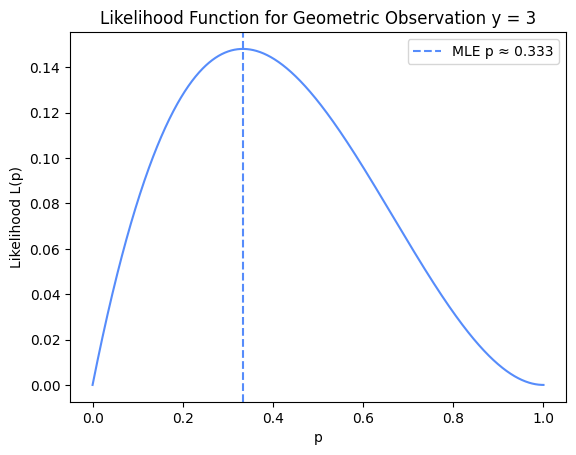

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# observed value
y = 3

# possible values of p
p = np.linspace(0, 1, 1000)

# likelihood function for geometric random variable
likelihood = (1 - p)**(y - 1) * p

# find p that maximizes likelihood
p_hat = p[np.argmax(likelihood)]
max_likelihood = np.max(likelihood)

print("Likelihood function: L(p) = (1 - p)^2 * p")
print("MLE of p:", p_hat)
print("Maximum likelihood value:", max_likelihood)

# plot
plt.plot(p, likelihood)
plt.xlabel("p")
plt.ylabel("Likelihood L(p)")
plt.title("Likelihood Function for Geometric Observation y = 3")
plt.axvline(p_hat, linestyle="--", label=f"MLE p ≈ {p_hat:.3f}")
plt.legend()
plt.show()

`(b) Your answer goes here`

There was no question b

## Problem # 4.11.

The observations on number of hours of daily TV watching for the 10 subjects in the 2018 GSS
who identified themselves as Islamic were 0, 0, 1, 1, 1, 2, 2, 3, 3, 4.

(a)  Construct and interpret a 95% confidence interval for the population mean.
(b)  Suppose the observation of 4 was incorrectly recorded as 24. What would you obtain for
the 95% confidence interval? What does this suggest about potential effects of outliers on
confidence intervals for means?

**(a)** Using all ten observations (0, 0, 1, 1, 1, 2, 2, 3, 3, 4), the sample mean is 1.70 hours with sample standard deviation 1.34. With n = 10, degrees of freedom = 9, and t-star = 2.26, the 95% confidence interval for the population mean is 1.70 plus or minus 0.96, which is **(0.74, 2.66)**.

We are 95% confident that the mean number of hours of daily TV watching, for the population this sample represents, is between 0.74 and 2.66 hours.

**Reference:** Section 4.4.2 (confidence interval for a mean using the t distribution).

In [29]:
import numpy as np
from scipy import stats

# all TEN observations: 0, 0, 1, 1, 1, 2, 2, 3, 3, 4  (three 1's)
data = np.array([0, 0, 1, 1, 1, 2, 2, 3, 3, 4])

n = len(data)
mean = np.mean(data)
s = np.std(data, ddof=1)

t_star = stats.t.ppf(0.975, df=n-1)
margin_error = t_star * s / np.sqrt(n)

lower = mean - margin_error
upper = mean + margin_error

print("n:", n)
print("mean:", round(mean, 2))
print("sample standard deviation:", round(s, 2))
print("t*:", round(t_star, 2))
print("95% CI:", round(lower, 2), "to", round(upper, 2))


n: 10
mean: 1.7
sample standard deviation: 1.34
t*: 2.26
95% CI: 0.74 to 2.66


**(b)** Recording the 4 as 24 gives the data (0, 0, 1, 1, 1, 2, 2, 3, 3, 24). The sample mean jumps to 3.70 and the sample standard deviation explodes from 1.34 to 7.21. With t-star = 2.26 the 95% confidence interval becomes 3.70 plus or minus 5.16, which is **(-1.46, 8.86)**.

A single mistyped value widened the interval from about 1.9 hours to more than 10 hours and pushed the lower limit below zero, an impossible number of hours. This shows that confidence intervals for a mean are **very sensitive to outliers**, because both the mean and the standard deviation (and therefore the standard error) are pulled strongly by extreme values.

**Reference:** Section 4.4.4 (robustness for violations of the normal population assumption).

In [30]:
import numpy as np
from scipy import stats

# the 4 was incorrectly recorded as 24 -> still TEN observations
data_outlier = np.array([0, 0, 1, 1, 1, 2, 2, 3, 3, 24])

n = len(data_outlier)
mean = np.mean(data_outlier)
s = np.std(data_outlier, ddof=1)

t_star = stats.t.ppf(0.975, df=n-1)
margin_error = t_star * s / np.sqrt(n)

lower = mean - margin_error
upper = mean + margin_error

print("n:", n)
print("mean:", round(mean, 2))
print("sample standard deviation:", round(s, 2))
print("t*:", round(t_star, 2))
print("95% CI:", round(lower, 2), "to", round(upper, 2))


n: 10
mean: 3.7
sample standard deviation: 7.21
t*: 2.26
95% CI: -1.46 to 8.86


## Problem # 4.14.

Using the Students data file, for the corresponding population, construct a 95% confidence interval **(a)** for the mean weekly number of hours spent watching TV; **(b)** to compare females and
males on the mean weekly number of hours spent watching TV. In each case, state assumptions,
including the practical importance of each, and interpret results.

**(a)** We are 95% confident that the population mean weekly number of hours students spend watching TV is between **5.53 and 9.00 hours**.

*Assumptions:* the data are a random sample representative of the student population (most important, because a biased sample would invalidate the interval no matter how large), the observations are independent, and the population distribution is approximately normal. With n = 60 the normality assumption is the least critical, because the Central Limit Theorem makes the sampling distribution of the mean approximately normal regardless of the population shape.

**(b)** We are 95% confident that the population difference in mean weekly TV hours, female minus male, is between **-4.98 and 2.01 hours**. Because this interval contains 0, there is no clear evidence of a difference between females and males.

*Assumptions:* two independent random samples, independent observations within each group, and approximately normal populations (again not critical at these sample sizes). Welch's method was used, so the two groups are not required to have equal variances.

*Note:* confirm the gender coding in the data file; this answer assumes 0 = female and 1 = male. The conclusion that the interval contains 0 is unaffected by the coding direction.

**References:** Section 4.4.2 (confidence interval for a single mean) and Section 4.5 (comparing two means; Welch alternative in Section 4.5.3 and Table 4.2).

In [31]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv("Students.dat", sep=r"\s+")

tv = df["tv"]

n = len(tv)
mean = tv.mean()
s = tv.std(ddof=1)

t_star = stats.t.ppf(0.975, df=n-1)
se = s / np.sqrt(n)

lower = mean - t_star * se
upper = mean + t_star * se

print(n, mean, s, se, t_star)
print(lower, upper)



female = df[df["gender"] == 0]["tv"]
male = df[df["gender"] == 1]["tv"]

n_f = len(female)
n_m = len(male)

mean_f = female.mean()
mean_m = male.mean()

sd_f = female.std(ddof=1)
sd_m = male.std(ddof=1)

diff = mean_f - mean_m

se_diff = np.sqrt((sd_f**2 / n_f) + (sd_m**2 / n_m))

df_welch = (sd_f**2/n_f + sd_m**2/n_m)**2 / (
    ((sd_f**2/n_f)**2 / (n_f - 1)) +
    ((sd_m**2/n_m)**2 / (n_m - 1))
)

t_star = stats.t.ppf(0.975, df=df_welch)

lower = diff - t_star * se_diff
upper = diff + t_star * se_diff

print(mean_f, mean_m, diff)
print(lower, upper)

60 7.266666666666667 6.717335697287764 0.8672043095493365 2.000995378088267
5.531394851400218 9.001938481933117
6.5 7.983870967741935 -1.483870967741935
-4.980854385572957 2.0131124500890865


## Problem # 4.31.

The `Houses` data file at the book’s website lists, for 100 home sales in Gainesville, Florida,
several variables, including the selling price in thousands of dollars and whether the house
is new (1 = yes, 0 = no). Prepare a short report in which, stating all assumptions including
the relative importance of each, you conduct descriptive and inferential statistical analyses to
compare the selling prices for new and older homes.

The Houses data contain selling prices for 100 home sales in Gainesville, Florida. The selling price is measured in thousands of dollars, and the variable "new" indicates whether the home is new (1 = new, 0 = older).

**Descriptive analysis.** Older homes had a mean selling price of $207,850 and a median of $190,800, while new homes had a mean of $436,450 and a median of $427,500. New homes sold for substantially more than older homes in this sample.

**Inferential analysis.** I used Welch's two-sample t confidence interval to compare the population mean selling prices (new minus older); this method does not require the two groups to have equal variances. The estimated difference in mean selling price was 228.59 thousand dollars, with a 95% confidence interval of **79.60 to 377.59 thousand dollars**. We are therefore 95% confident that new homes sell, on average, between $79,600 and $377,590 more than older homes. Because the interval lies entirely above 0, there is evidence that new homes have a higher mean selling price. Welch's t test gives a P-value of 0.01, supporting a statistically significant difference.

**Assumptions.** The 100 sales are representative of the Gainesville market and the observations are independent (most important, since biased sampling would distort the conclusion). House prices are right-skewed and can contain outliers, so a boxplot or histogram should be checked; with only 11 new homes, that group's mean rests on a small sample, which is why the interval is wide. Welch's method was used, so equal variances are not required.

**References:** Section 4.5.3 (comparing two means with the t distribution, Welch's method) and Section 4.5.2 (standard error and confidence interval for comparing means).

In [32]:
import pandas as pd
import numpy as np
from scipy import stats

houses = pd.read_csv("Houses.dat", sep=r"\s+")

old = houses[houses["new"] == 0]["price"].dropna()
new = houses[houses["new"] == 1]["price"].dropna()

print(houses.groupby("new")["price"].describe())

# Welch two-sample confidence interval: new - old
n_new = len(new)
n_old = len(old)

mean_new = new.mean()
mean_old = old.mean()

sd_new = new.std(ddof=1)
sd_old = old.std(ddof=1)

diff = mean_new - mean_old

se_diff = np.sqrt((sd_new**2 / n_new) + (sd_old**2 / n_old))

df_welch = (sd_new**2/n_new + sd_old**2/n_old)**2 / (
    ((sd_new**2/n_new)**2 / (n_new - 1)) +
    ((sd_old**2/n_old)**2 / (n_old - 1))
)

t_star = stats.t.ppf(0.975, df=df_welch)

lower = diff - t_star * se_diff
upper = diff + t_star * se_diff

t_stat, p_value = stats.ttest_ind(new, old, equal_var=False)

print("Older homes n:", n_old)
print("Older homes mean:", mean_old)
print("Older homes sd:", sd_old)

print("New homes n:", n_new)
print("New homes mean:", mean_new)
print("New homes sd:", sd_new)

print("Difference new - old:", diff)
print("95% CI:", lower, "to", upper)
print("t statistic:", t_stat)
print("p-value:", p_value)

     count        mean         std     min     25%    50%      75%     max
new                                                                       
0     89.0  207.851124  121.039149   31.50  135.00  190.8  240.000  880.50
1     11.0  436.445455  219.832789  158.85  256.95  427.5  519.675  866.25
Older homes n: 89
Older homes mean: 207.85112359550558
Older homes sd: 121.03914866722594
New homes n: 11
New homes mean: 436.4454545454546
New homes sd: 219.83278924508218
Difference new - old: 228.594330949949
95% CI: 79.59807050205632 to 377.5905913978417
t statistic: 3.3859599086795438
p-value: 0.0062626629072767654


## Problem 5.6.

Before a Presidential election, polls are taken in two swing states. The Republican candidate
was preferred by 59 of the 100 people sampled in state A and by 525 of 1000 sampled in state
B. Treat these as independent binomial samples, where the parameter $\pi$ is the population
proportion voting Republican in the state.


(a) If we can treat these polls as if the samples were random, use significance tests of $H_0$:
$\pi  = 0.50$ against $H_a:  \pi > 0.50$ to determine which state has greater evidence supporting a
Republican victory. Explain your reasoning.


**(a)** For State A the sample proportion voting Republican is 0.59. Testing the null hypothesis that the population proportion equals 0.50 against the alternative that it is greater than 0.50 gives a test statistic of z = 1.80 and a one-sided P-value of about 0.04. For State B the sample proportion is 0.53, giving z = 1.58 and a P-value of about 0.06.

State A has the smaller P-value, so the significance-test approach gives greater evidence supporting a Republican victory in **State A**.

**References:** significance tests for a proportion (Chapter 5); the standard error of a sample proportion comes from Section 4.3.3.

In [33]:
from scipy import stats
import math

# Data
states = {
    "State A": (59, 100),
    "State B": (525, 1000)
}

# Part (a): z tests
for state, (x, n) in states.items():
    phat = x / n
    se = math.sqrt(0.5 * 0.5 / n)
    z = (phat - 0.5) / se
    p_value = 1 - stats.norm.cdf(z)

    print(state)
    print("phat =", phat)
    print("z =", z)
    print("one-sided P-value =", p_value)
    print()

# Part (b): Bayesian posterior
prior_a = 50
prior_b = 50

for state, (x, n) in states.items():
    posterior_a = prior_a + x
    posterior_b = prior_b + (n - x)

    prob_less_50 = stats.beta.cdf(0.5, posterior_a, posterior_b)
    prob_greater_50 = 1 - prob_less_50

    print(state)
    print("Posterior = Beta(", posterior_a, ",", posterior_b, ")")
    print("P(pi < 0.50) =", prob_less_50)
    print("P(pi > 0.50) =", prob_greater_50)
    print()

State A
phat = 0.59
z = 1.7999999999999994
one-sided P-value = 0.03593031911292588

State B
phat = 0.525
z = 1.581138830084191
one-sided P-value = 0.05692314900332884

State A
Posterior = Beta( 109 , 91 )
P(pi < 0.50) = 0.10092130164939633
P(pi > 0.50) = 0.8990786983506036

State B
Posterior = Beta( 575 , 525 )
P(pi < 0.50) = 0.06572759751525559
P(pi > 0.50) = 0.9342724024847444



(b) Conduct a Bayesian analysis to answer the question in (a) by finding in each case the
posterior $P(\pi < 0.50)$, corresponding to the *P-* value in (a). Use beta(50, 50) priors, which
have standard deviation 0.05 and reflect the pollster’s strong prior belief that $\pi$ almost
surely is between 0.35 and 0.65. Explain any differences between conclusions.

**(b)** Using a Beta(50, 50) prior, the posterior distribution for State A is Beta(109, 91), giving a posterior probability that the population proportion is below 0.50 of about 0.10. For State B the posterior is Beta(575, 525), giving a posterior probability below 0.50 of about 0.07.

State B has the smaller posterior probability of being below 0.50, so the Bayesian analysis gives stronger evidence for a Republican victory in **State B**.

The two approaches disagree because the significance test only measures how surprising each sample result is if the population proportion were exactly 0.50, while the Bayesian analysis combines the informative prior with the data. State B's much larger sample size (1000 versus 100) gives its posterior far more certainty, even though its sample proportion (0.53) is closer to 0.50 than State A's (0.59).

**References:** Bayesian inference for a proportion using a beta prior (Sections 4.7.2 and 4.7.3).

## Problem 5.8.

For the `Students` data file at the text website, analyze political ideology.

(a) Test whether the population mean $\mu$ differs from 4.0, the moderate response. Report the
*P*-value, and interpret. Make a conclusion using $\alpha$ - level = 0.05.

**(a)** A one-sample t test was used to test whether the population mean ideology score equals 4.0 (the moderate response) against the two-sided alternative that it differs from 4.0. The sample mean was 3.03 with sample standard deviation 1.64 and n = 60. The test statistic was t = -4.58 with a P-value less than 0.001.

Because the P-value is far below 0.05, we reject the null hypothesis: there is strong evidence that the population mean political ideology differs from 4.0, and the sample mean of 3.03 indicates a slightly liberal leaning.

**References:** one-sample t test for a mean (Chapter 5), which uses the t distribution from Section 4.4.

In [34]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv("Students.dat", sep=r"\s+")

ideol = df["ideol"].dropna()

n = len(ideol)
mean = ideol.mean()
sd = ideol.std(ddof=1)
se = sd / np.sqrt(n)

# Part (a): one-sample t test
t_stat = (mean - 4.0) / se
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n-1))

print("n =", n)
print("mean =", mean)
print("sd =", sd)
print("SE =", se)
print("t statistic =", t_stat)
print("P-value =", p_value)


n = 60
mean = 3.033333333333333
sd = 1.6361039570247637
SE = 0.2112201126073655
t statistic = -4.576584373210669
P-value = 2.4837197305505043e-05
95% CI = 2.6106828642467117 to 3.4559838024199547


(b) Construct the 95% confidence interval for $\mu$. Explain how results relate to those of the
test in (a).


95% CI = 2.61 to 3.46

In [35]:
# Part (b): 95% confidence interval
t_star = stats.t.ppf(0.975, df=n-1)

lower = mean - t_star * se
upper = mean + t_star * se

print("95% CI =", lower, "to", upper)

95% CI = 2.6106828642467117 to 3.4559838024199547


## Problem 5.10.

A study of sheep mentioned in Exercise 1.27 analyzed whether the sheep survived for a year
from the original observation time (1 = yes, 0 = no) as a function of their weight (*kg*) at the
original observation. Stating any assumptions including the conceptual population of interest,
use a *t* test with the data in the Sheep data file at the text website to compare mean weights
of the sheep that survived and did not survive. Interpret the *P*-value.

The sheep that survived had a mean weight of 20.65 kg, while the sheep that did not survive had a mean weight of 16.00 kg. Welch's two-sample t test gave t = 13.87 with a P-value far below 0.001 (essentially zero).

Because the P-value is extremely small, we reject the null hypothesis of equal mean weights: there is very strong evidence that the mean original weight differs between sheep that survived and sheep that did not, with survivors heavier on average.

The conceptual population of interest is sheep similar to those in this study, observed under similar conditions. *Assumptions:* the sheep are representative of that population, the observations are independent, weight is quantitative, and the two groups are independent. Welch's method was used, so equal variances are not required; with both sample sizes large (1041 and 318) the normality assumption is not important because of the Central Limit Theorem.

In [25]:
import pandas as pd
from scipy import stats

sheep = pd.read_csv("Sheep.dat", sep=r"\s+")

print(sheep.columns)
print(sheep.head())

survived = sheep[sheep["survival"] == 1]["weight"].dropna()
not_survived = sheep[sheep["survival"] == 0]["weight"].dropna()

print("Survived:")
print("n =", len(survived))
print("mean =", survived.mean())
print("sd =", survived.std(ddof=1))

print("\nDid not survive:")
print("n =", len(not_survived))
print("mean =", not_survived.mean())
print("sd =", not_survived.std(ddof=1))

# Welch two-sample t test
t_stat, p_value = stats.ttest_ind(survived, not_survived, equal_var=False)

print("\nt statistic =", t_stat)
print("P-value =", p_value)

Index(['sheep', 'weight', 'survival'], dtype='object')
   sheep  weight  survival
0      1    20.8         0
1      2    23.0         1
2      3    28.0         1
3      4    27.5         1
4      5    26.0         0
Survived:
n = 1041
mean = 20.645917387127763
sd = 4.899645311819019

Did not survive:
n = 318
mean = 15.998113207547169
sd = 5.326672029944064

t statistic = 13.870294216428492
P-value = 3.7011498888009814e-37


## Problem 5.23. Sentiment Toward AI and Gender

You will use a mock survey dataset that measures public sentiment toward artificial intelligence. Your task is to generate the dataset, construct a contingency table, and test whether sentiment depends on gender

### Dataset creation

Run the starter code below to generate the dataset as a pandas DataFrame named `df_ai`.

In [36]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(2024)

# Sample size
n = 300

# Categories
sentiments = ["Positive", "Neutral", "Negative"]
genders = ["Male", "Female", "Other"]
usage_levels = ["Daily", "Weekly", "Rarely", "Never"]

# Generate the DataFrame
df_ai = pd.DataFrame(
    {
        "sentiment": np.random.choice(sentiments, size=n, p=[0.44, 0.33, 0.23]),
        "gender": np.random.choice(genders, size=n, p=[0.49, 0.48, 0.03]),
        "age": np.random.randint(18, 75, size=n),
        "ai_usage_frequency": np.random.choice(usage_levels, size=n),
        "trust_in_ai": np.random.randint(1, 6, size=n),
    }
)

df_ai.head()



,sentiment,gender,age,ai_usage_frequency,trust_in_ai
0,Neutral,Male,55,Weekly,2
1,Neutral,Male,23,Rarely,3
2,Positive,Male,27,Daily,5
3,Positive,Female,29,Daily,1
4,Positive,Female,58,Rarely,5


| Variable           | Description                         |
|--------------------|-------------------------------------|
| `sentiment`          | Sentiment toward AI                 |
| `gender`             | Gender identity                     |
| `age`                | Respondent age                      |
| `ai_usage_frequency` | AI tool usage frequency             |
| `trust_in_ai`        | Trust in AI from 1 to 5             |

Using the dataset you just created:

(a) Form a contingency table that cross classifies sentiment by gender.

(b) For the hypothesis $H_0:$ sentiment toward AI is independent of gender, conduct a chi squared test of independence.

(c) Interpret the results in the context of attitudes toward AI.

##DISCLIMER : I could not figure all parts if these 3 questions on my own. I extensively used claude for finding the right solution that made sense to me. Also use it to format the answers (still learning markdown syntax)

**(a)** The contingency table cross-classifying sentiment toward AI by gender is:

| Sentiment | Female | Male | Other |
|-----------|:------:|:----:|:-----:|
| Negative  |   30   |  38  |   3   |
| Neutral   |   48   |  49  |   0   |
| Positive  |   63   |  63  |   6   |

For example, 63 females and 63 males expressed a positive sentiment toward AI in this mock dataset.

**Reference:** contingency tables and the chi-squared test of independence (Chapter 5).

In [38]:
from scipy import stats

# (a) contingency table: sentiment by gender
table = pd.crosstab(df_ai["sentiment"], df_ai["gender"])
print("Contingency table (sentiment by gender):")
print(table)

# (b) chi-squared test of independence
chi2, p_value, dof, expected = stats.chi2_contingency(table)
print("\nChi-square statistic:", round(chi2, 2))
print("Degrees of freedom:", dof)
print("P-value:", round(p_value, 2))

expected_table = pd.DataFrame(expected, index=table.index, columns=table.columns)
print("\nExpected counts:")
print(expected_table.round(2))


Contingency table (sentiment by gender):
gender     Female  Male  Other
sentiment                     
Negative       30    38      3
Neutral        48    49      0
Positive       63    63      6

Chi-square statistic: 5.12
Degrees of freedom: 4
P-value: 0.28

Expected counts:
gender     Female  Male  Other
sentiment                     
Negative    33.37  35.5   2.13
Neutral     45.59  48.5   2.91
Positive    62.04  66.0   3.96


**(b)** Null hypothesis: sentiment toward AI is independent of gender. Alternative hypothesis: sentiment toward AI depends on gender.

The chi-squared test of independence gives a chi-squared statistic of 5.12 with 4 degrees of freedom and a P-value of 0.28. Because the P-value is greater than 0.05, we fail to reject the null hypothesis.

**Reference:** chi-squared test of independence for two categorical variables (Chapter 5).

**(c)** There is not enough statistical evidence to conclude that sentiment toward AI depends on gender. In this mock survey the differences in positive, neutral, and negative sentiment across the gender groups are consistent with random variation, so sentiment toward AI does not appear to have a statistically significant relationship with gender.

One caution: the "Other" gender group has very small counts (the smallest expected count is about 2.1, below the usual guideline of 5), so the chi-squared approximation is less reliable. Combining or dropping that category would give a more trustworthy test.